In [1]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("nudratabbas/healthcare-fraud-detection-dataset")

print("Path to dataset files:", path)

C:\Users\larin\AppData\Local\Programs\Python\Python314\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Path to dataset files: C:\Users\larin\.cache\kagglehub\datasets\nudratabbas\healthcare-fraud-detection-dataset\versions\1


In [2]:
import pandas as pd
import numpy as np
df = pd.read_csv(path + "/healthcare_fraud_detection.csv") 
df.head(4)

,Provider_ID,Claim_ID,Patient_Age,Patient_Gender,Diagnosis_Code,Procedure_Code,Claim_Amount,Approved_Amount,Insurance_Type,Claim_Submission_Date,Days_Between_Service_and_Claim,Number_of_Claims_Per_Provider_Monthly,Provider_Specialty,Patient_State,Claim_Status,Is_Fraud,Length_of_Stay,Visit_Type,Chronic_Condition_Flag,Prior_Visits_12m
0,P0052,C0000000,37,Male,I25.10,36415,443.51,393.16,Medicaid,2024-09-01,13,70,Cardiology,NY,Approved,0,0,Outpatient,1,2.0
1,P0121,C0000001,21,Female,E11.9,99213,467.50,461.33,Self-Pay,2022-09-05,5,62,General Practice,IL,Pending,0,5,Inpatient,1,2.0
2,P0140,C0000002,78,Female,J06.9,93000,591.69,530.06,Medicaid,2022-04-11,29,60,Cardiology,IL,Pending,0,5,Inpatient,1,3.0
3,P0202,C0000003,65,Male,I10,93000,235.15,189.11,Private,2023-10-11,22,70,General Practice,TX,Approved,0,0,Emergency,0,5.0


In [4]:
(df.pivot_table(index='Provider_ID',  values='Is_Fraud', aggfunc= 'mean')).sort_values(by = 'Is_Fraud', ascending = False)

,Is_Fraud
Provider_ID,
P0086,0.421053
P0159,0.350000
P0110,0.333333
P0104,0.323529
P0223,0.318182
...,...
P0053,0.000000
P0031,0.000000
P0024,0.000000


In [5]:
(df.pivot_table(index='Chronic_Condition_Flag',  values='Is_Fraud', aggfunc= 'mean')*100).sort_values(by = 'Is_Fraud', ascending = False)

,Is_Fraud
Chronic_Condition_Flag,
1,8.664384
0,8.135593


In [6]:
df['(%)_Approved_amount'] = df['Approved_Amount'] / df['Claim_Amount']*100
provider_chronic= df.pivot_table(index=['Is_Fraud'], values=['Claim_Amount', 'Approved_Amount','(%)_Approved_amount'], aggfunc= 'mean').sort_index(ascending=False)
provider_chronic

,(%)_Approved_amount,Approved_Amount,Claim_Amount
Is_Fraud,,,
1,54.74607,545.871978,990.931797
0,87.60123,469.154258,535.008352


In [7]:
df['all'] = 1
total_percent_of_fraud= df.pivot_table(index=['all'], values=['Is_Fraud'], aggfunc= 'mean')*100
total_percent_of_fraud

,Is_Fraud
all,
1,8.29


In [8]:
fraud_amount_on_Provider= df.pivot_table(index=['Provider_ID'], values=['Claim_Amount', 'Approved_Amount','(%)_Approved_amount', 'Is_Fraud'], aggfunc= 'mean').sort_values(by= 'Is_Fraud', ascending = False)
fraud_amount_on_Provider
fraud_amount_on_Provider['cat_of_fraud'] = fraud_amount_on_Provider.apply(
    lambda row:
        'L >=44% Fraud'          if row['Is_Fraud'] >= 0.44
        else 'K 40-43% Fraud'    if row['Is_Fraud'] >= 0.40
        else 'J 36-39% Fraud'    if row['Is_Fraud'] >= 0.36
        else 'I 32-35% Fraud'    if row['Is_Fraud'] >= 0.32
        else 'H 28-31% Fraud'    if row['Is_Fraud'] >= 0.28
        else 'G 24-27% Fraud'    if row['Is_Fraud'] >= 0.24
        else 'F 20-23% Fraud'    if row['Is_Fraud'] >= 0.20
        else 'E 16-19% Fraud'    if row['Is_Fraud'] >= 0.16
        else 'D 12-15% Fraud'    if row['Is_Fraud'] >= 0.12
        else 'C 8-11% Fraud'    if row['Is_Fraud'] >= 0.08
        else 'B 4-7% Fraud'     if row['Is_Fraud'] >= 0.04
        else 'A 0-3% Fraud',
    axis=1
)
fraud_amount_on_Provider.rename(columns = {'(%)_Approved_amount':'mean_%ApprovedAmount','Approved_Amount':'mean_ApprovedAmount','Claim_Amount':'mean_ClaimAmount'},inplace = True)
fraud_amount_on_Provider

,mean_%ApprovedAmount,mean_ApprovedAmount,mean_ClaimAmount,Is_Fraud,cat_of_fraud
Provider_ID,,,,,
P0086,74.367500,462.962368,665.087632,0.421053,K 40-43% Fraud
P0159,77.468365,406.384000,538.148500,0.350000,I 32-35% Fraud
P0110,76.993076,588.914000,792.715778,0.333333,I 32-35% Fraud
P0104,76.964715,452.506471,611.525882,0.323529,I 32-35% Fraud
P0223,76.658841,582.862727,800.208864,0.318182,H 28-31% Fraud
...,...,...,...,...,...
P0053,89.182627,570.407727,622.512727,0.000000,A 0-3% Fraud
P0031,89.558764,425.320870,484.307826,0.000000,A 0-3% Fraud
P0024,86.917656,452.291053,531.676579,0.000000,A 0-3% Fraud


In [9]:
agregateFraud= df.pivot_table(index=['Provider_ID'], values=['Is_Fraud'], aggfunc= 'sum').sort_values(by= 'Is_Fraud', ascending = False)
agregateFraud.rename(columns={'Is_Fraud':'Counted_Fraud_Claims'}, inplace=True)
fraud_amount_on_Provider = pd.merge(fraud_amount_on_Provider, agregateFraud, on = 'Provider_ID')
fraud_amount_on_Provider

,mean_%ApprovedAmount,mean_ApprovedAmount,mean_ClaimAmount,Is_Fraud,cat_of_fraud,Counted_Fraud_Claims
Provider_ID,,,,,,
P0086,74.367500,462.962368,665.087632,0.421053,K 40-43% Fraud,16
P0159,77.468365,406.384000,538.148500,0.350000,I 32-35% Fraud,7
P0110,76.993076,588.914000,792.715778,0.333333,I 32-35% Fraud,15
P0104,76.964715,452.506471,611.525882,0.323529,I 32-35% Fraud,11
P0223,76.658841,582.862727,800.208864,0.318182,H 28-31% Fraud,14
...,...,...,...,...,...,...
P0053,89.182627,570.407727,622.512727,0.000000,A 0-3% Fraud,0
P0031,89.558764,425.320870,484.307826,0.000000,A 0-3% Fraud,0
P0024,86.917656,452.291053,531.676579,0.000000,A 0-3% Fraud,0


In [10]:
import matplotlib.pyplot as plt

categorized_Fraud= fraud_amount_on_Provider.reset_index().pivot_table(index=['cat_of_fraud'], values=['mean_%ApprovedAmount','mean_ClaimAmount'], aggfunc= 'median').sort_values(by = 'mean_%ApprovedAmount', ascending= False)
median_Fraud = fraud_amount_on_Provider.reset_index().pivot_table(index=['cat_of_fraud'], values=['Is_Fraud'], aggfunc= 'median')
count_Fraud = fraud_amount_on_Provider.reset_index().pivot_table(index=['cat_of_fraud'], values=['Counted_Fraud_Claims'], aggfunc= 'sum')
#count_Fraud = count_Fraud.rename(columns= {'Counted_Fraud_Claims':'Count_Claims'})
categorized_Fraud = pd.merge(categorized_Fraud,count_Fraud,on='cat_of_fraud' )
categorized_Fraud['%_Fraud_Claims'] = categorized_Fraud['Counted_Fraud_Claims']/np.sum(categorized_Fraud['Counted_Fraud_Claims'])
categorized_Fraud



,mean_%ApprovedAmount,mean_ClaimAmount,Counted_Fraud_Claims,%_Fraud_Claims
cat_of_fraud,,,,
A 0-3% Fraud,86.981201,541.178412,52,0.062726
B 4-7% Fraud,85.749209,566.351351,199,0.240048
C 8-11% Fraud,84.791654,558.384000,212,0.255730
D 12-15% Fraud,83.124512,592.967846,127,0.153197
E 16-19% Fraud,82.162406,616.008267,73,0.088058
F 20-23% Fraud,80.745315,615.917059,49,0.059107
G 24-27% Fraud,79.102383,669.857703,36,0.043426
H 28-31% Fraud,77.523762,653.342121,32,0.038601
I 32-35% Fraud,76.993076,611.525882,33,0.039807


Наблюдаем чёткий тренд на снижение одобряемой доли страховой выплаты от запрашиваемой суммы,
при росте запрашиваемой суммы. При этом Большая часть фродовых запросов соредоточена в сегментах B,C,D


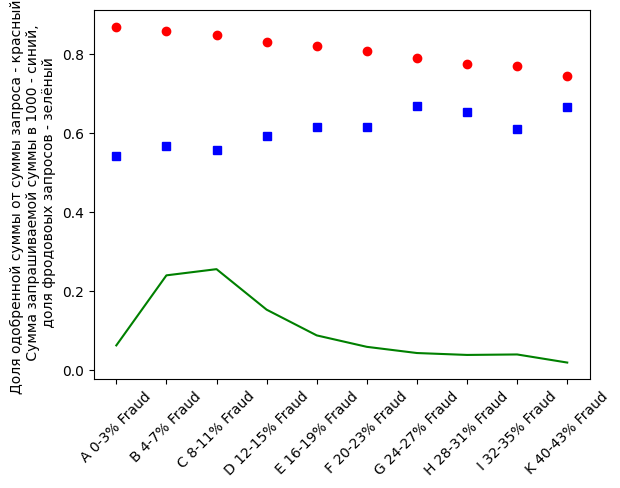

In [11]:
plt.plot(categorized_Fraud['mean_%ApprovedAmount']/100, 'ro',categorized_Fraud['mean_ClaimAmount']/1000, 'bs', categorized_Fraud['%_Fraud_Claims'], 'g')
plt.ylabel('Доля одобренной суммы от суммы запроса - красный.\n Сумма запрашиваемой суммы в 1000 - синий,\n доля фродовоых запросов - зелёный')
plt.xticks(rotation=45)
print('Наблюдаем чёткий тренд на снижение одобряемой доли страховой выплаты от запрашиваемой суммы,\nпри росте запрашиваемой суммы. При этом Большая часть фродовых запросов соредоточена в сегментах B,C,D')
plt.show()

In [89]:
DBSaC_medianAmount = df.pivot_table(index='Days_Between_Service_and_Claim',  values=['Claim_Amount','Approved_Amount'], aggfunc= 'median').sort_index(ascending = False)
DBSaC_and_fraud = df.pivot_table(index='Days_Between_Service_and_Claim',  values=['Is_Fraud','all'], aggfunc= 'sum').sort_index(ascending = False)
DBSaC_and_fraud = pd.merge(DBSaC_and_fraud,DBSaC_medianAmount, on='Days_Between_Service_and_Claim')
DBSaC_and_fraud['%ApprovedAmount'] = DBSaC_and_fraud['Approved_Amount']/DBSaC_and_fraud['Claim_Amount']
DBSaC_and_fraud

,Is_Fraud,all,Approved_Amount,Claim_Amount,%ApprovedAmount
Days_Between_Service_and_Claim,,,,,
29,0,334,367.915,437.960,0.840065
28,0,329,383.090,431.440,0.887933
27,0,306,370.710,433.670,0.854820
26,0,323,355.500,416.130,0.854300
25,0,322,386.290,457.295,0.844728
24,0,329,360.370,422.030,0.853897
23,0,379,375.150,430.050,0.872340
22,0,300,402.015,467.185,0.860505
21,0,307,379.860,429.590,0.884238



Наблюдаем корреляцию:
 Больше дней = меньше фрода.


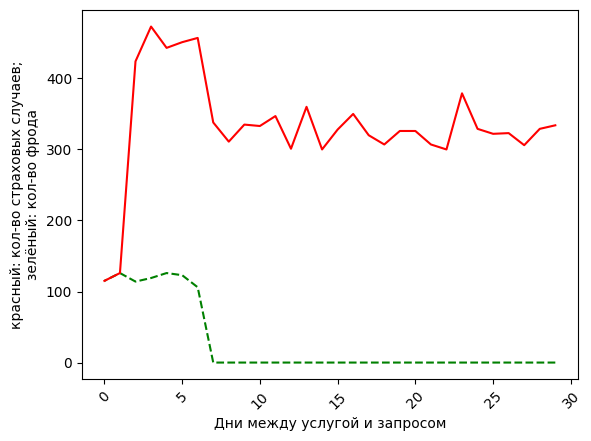


 Медианная запрошенная сумма значительно выше в случаях, где сумма дней между запросом и услугой стремиться к минимуму.
 Что закономерно отражает корреляцию между количеством дней и фродом.


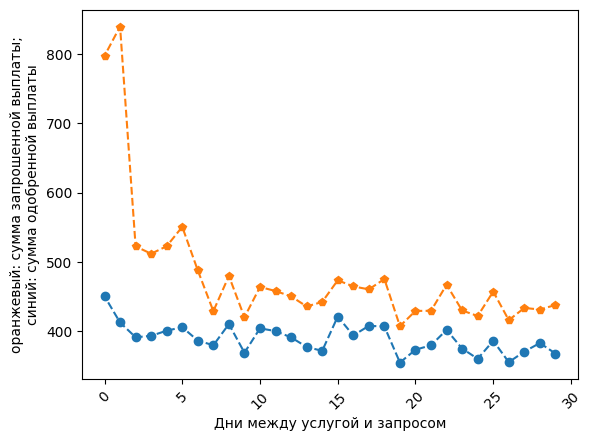

In [74]:
plt.figure()
plt.subplot(111)
plt.plot(DBSaC_and_fraud['Is_Fraud'],'g--',DBSaC_and_fraud['all'],'r')
plt.ylabel('красный: кол-во страховых случаев;\nзелёный: кол-во фрода')
plt.xlabel('Дни между услугой и запросом')
plt.xticks(rotation=45)
print('\nНаблюдаем корреляцию:\n Больше дней = меньше фрода.')
plt.show()

plt.subplot(111)
plt.plot(DBSaC_and_fraud['Approved_Amount'],'o--',DBSaC_and_fraud['Claim_Amount'],'p--')
plt.ylabel('оранжевый: сумма запрошенной выплаты;\nсиний: сумма одобренной выплаты')
plt.xlabel('Дни между услугой и запросом')
plt.xticks(rotation=45)
print('\n Медианная запрошенная сумма значительно выше в случаях, где сумма дней между запросом и услугой стремиться к минимуму.\n Что закономерно отражает корреляцию между количеством дней и фродом.')
plt.show()

Построим следующие точечные графики, где желтым цветом отразим фродовые заявки, фиолетовым заявки без маркера фрода:


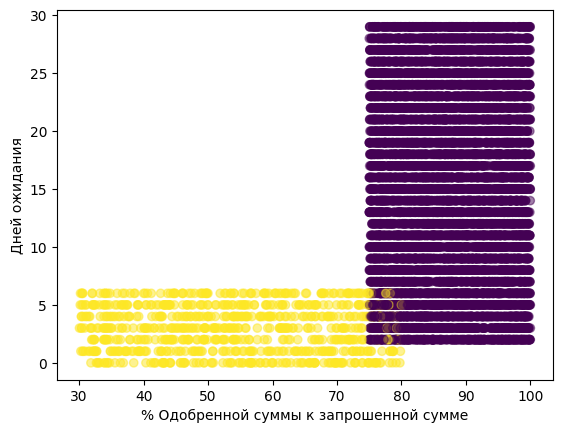

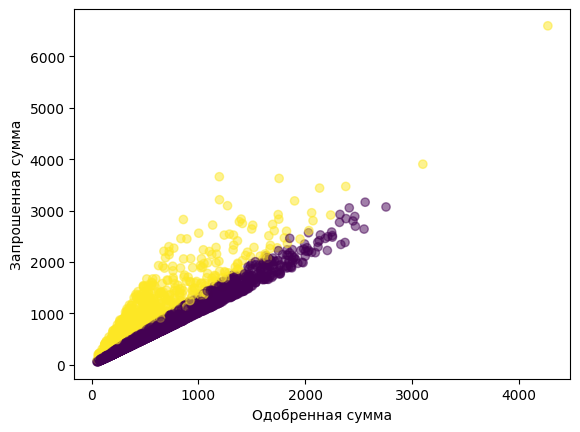

In [161]:
print('Построим следующие точечные графики, где желтым цветом отразим фродовые заявки, фиолетовым заявки без маркера фрода:')
plt.figure()

plt.subplot(111)
plt.ylabel('Дней ожидания')
plt.xlabel('% Одобренной суммы к запрошенной сумме')
plt.scatter(df['(%)_Approved_amount'],df['Days_Between_Service_and_Claim'], c=df['Is_Fraud'], alpha=0.5)
plt.show()

plt.subplot(111)
plt.ylabel('Запрошенная сумма')
plt.xlabel('Одобренная сумма')
plt.scatter(df['Approved_Amount'],df['Claim_Amount'], c=df['Is_Fraud'], alpha=0.5)
plt.show()

Выявлены следующие признаки для мошеннических заявок:
1. *Для мошеннических операций в приведённом датасете характерна низкая задержка между оказанием услуги и подачей запроса*;
2. *Для мошеннических характерна большая разница между запрошенной страховой суммой и суммой одобренной для возмещения, когда для обычных заявок отношение запрошенной суммы к одобренной ближе к пропорции 1:1*;

In [ ]:
train_ds = 